# Consultas ao Trino — Visão Gold PITCIC

Este notebook mostra como consultar o Lakehouse diretamente do Trino,
usando a visão `gold.pitcic` (**P**rocesso de **I**ntegração **T**erreno / Meteorologia /
**I**nimigo / **C**ivis — EB70-MC-10.336) como exemplo.

Dois jeitos de trabalhar com o resultado de uma consulta:

1. **Consulta direta no Trino** — o motor faz o processamento (agregação, filtro, join)
   em cima dos arquivos Parquet no MinIO e você só recebe o resultado final. Ideal
   quando você não precisa de todas as linhas, só de um resumo.
2. **Baixar tudo e usar pandas** — traz o resultado completo para um `DataFrame` e
   manipula localmente. Ideal quando você vai cruzar com outras fontes, fazer
   transformações linha a linha ou plotar gráficos personalizados.

## Pré-requisitos

- Stack no ar: `docker compose up -d` (Trino expõe `localhost:8090`, sem autenticação).
- Pipeline já rodou pelo menos uma vez, nesta ordem, para a `gold.pitcic` ter dados:
  `dag_ingestao_bronze` → `dag_silver_transform` → `dag_gold_refresh`.
- Dependências do venv local instaladas (`trino`, `pandas`, `matplotlib` —
  ver `requirements.txt` na raiz do repo).
- Um kernel Jupyter apontando pro venv (senão o Jupyter usa o Python global, que não
  tem essas libs):
  ```bash
  ./venv/Scripts/python.exe -m ipykernel install --user --name lakehouse-venv --display-name "Python (Lakehouse venv)"
  ./venv/Scripts/python.exe -m jupyter lab
  ```
  Depois selecione o kernel **Python (Lakehouse venv)** neste notebook.

In [1]:
import trino
import pandas as pd
import matplotlib.pyplot as plt

conn = trino.dbapi.connect(
    host="localhost",
    port=8090,
    user="notebook",   # Trino local não tem autenticação — qualquer nome serve
    catalog="iceberg",
    schema="gold",
)


def query_df(sql: str) -> pd.DataFrame:
    """Executa uma query no Trino e retorna o resultado como DataFrame pandas."""
    cur = conn.cursor()
    cur.execute(sql)
    linhas = cur.fetchall()
    colunas = [c[0] for c in cur.description]
    return pd.DataFrame(linhas, columns=colunas)

## 1. Conferindo o que existe no catálogo

O catálogo `iceberg` expõe as três camadas do medallion como schemas: `bronze`, `silver` e `gold`.

In [2]:
query_df("SHOW SCHEMAS FROM iceberg")

,Schema
0,bronze
1,default
2,gold
3,information_schema
4,silver


In [3]:
query_df("SHOW TABLES FROM iceberg.gold")

,Table
0,avaliacao
1,coc
2,pitcic
3,ppcot


## 2. Padrão A — consulta direta no Trino

O Trino faz o trabalho (agregação, filtro, join) sobre os dados armazenados como
Parquet/Iceberg no MinIO; só o resultado final trafega até o notebook.

### Ranking dos batalhões por atividade de ameaça

In [4]:
df_ranking = query_df("""
    SELECT
        batalhao_origem,
        total_obstaculos,
        obstaculos_intransponiveis,
        sensores_ativos,
        bateria_media_pct,
        total_ameacas_intel,
        nivel_ameaca_max,
        fogos_executados
    FROM gold.pitcic
    ORDER BY total_ameacas_intel DESC
""")
df_ranking

,batalhao_origem,total_obstaculos,obstaculos_intransponiveis,sensores_ativos,bateria_media_pct,total_ameacas_intel,nivel_ameaca_max,fogos_executados
0,1BPE,643,0,4,52.1,691,CRITICO,146
1,1BIB,628,0,5,57.7,663,CRITICO,160
2,2BPE,648,0,4,42.3,651,CRITICO,152
3,3BPE,625,0,7,49.6,634,CRITICO,164
4,4BPE,669,0,3,58.6,634,CRITICO,157
5,2BIB,665,0,3,48.5,615,CRITICO,151
6,5BPE,622,0,4,61.8,612,CRITICO,174


### Filtro — só batalhões com nível de ameaça ALTO ou CRÍTICO

In [5]:
query_df("""
    SELECT batalhao_origem, nivel_ameaca_max, total_ocorrencias_seg, baixas_proprias_seg
    FROM gold.pitcic
    WHERE nivel_ameaca_max IN ('ALTO', 'CRITICO')
    ORDER BY baixas_proprias_seg DESC
""")

,batalhao_origem,nivel_ameaca_max,total_ocorrencias_seg,baixas_proprias_seg
0,1BIB,CRITICO,695,710
1,2BPE,CRITICO,653,647
2,4BPE,CRITICO,639,626
3,2BIB,CRITICO,615,621
4,5BPE,CRITICO,635,610
5,1BPE,CRITICO,639,602
6,3BPE,CRITICO,624,588


> **Nota de implementação:** `nivel_ameaca_max` é calculado na transformação Gold
> (`spark/jobs/silver_to_gold.py`) com um ranking explícito de severidade
> (`BAIXO` < `MEDIO` < `ALTO` < `CRITICO`), e não com `MAX()` direto sobre a string —
> alfabeticamente `MEDIO` venceria `CRITICO`, invertendo a ordem doutrinária.
> Como os dados sintéticos cobrem todos os níveis, o esperado é que todos os
> batalhões apareçam aqui com `CRITICO`.

### Cruzando camadas num JOIN — Gold + Silver

A visão Gold já vem pré-agregada, mas nada impede consultar direto a camada Silver
(o dado "cru", só tipado) e até cruzar as duas num JOIN — por exemplo, para ver o
detalhe dos Pedidos de Apoio de Fogo urgentes nos batalhões mais ameaçados.

In [6]:
query_df("""
    SELECT
        p.batalhao_origem,
        p.total_ameacas_intel,
        f.tipo_alvo,
        f.status_execucao,
        COUNT(*) AS qtde_pedidos
    FROM gold.pitcic p
    JOIN silver.paf f ON f.batalhao_origem = p.batalhao_origem
    WHERE f.prioridade = 'URGENTE'
    GROUP BY p.batalhao_origem, p.total_ameacas_intel, f.tipo_alvo, f.status_execucao
    ORDER BY p.total_ameacas_intel DESC, qtde_pedidos DESC
""")

,batalhao_origem,total_ameacas_intel,tipo_alvo,status_execucao,qtde_pedidos
0,1BPE,691,POSICAO_DEFENSIVA,APROVADO,19
1,1BPE,691,AREA_SUSPEITA,EXECUTADO,14
2,1BPE,691,VEICULO,APROVADO,14
3,1BPE,691,PESSOAL_DESCOBERTO,APROVADO,14
4,1BPE,691,VEICULO,CANCELADO,13
...,...,...,...,...,...
135,5BPE,612,AREA_SUSPEITA,APROVADO,9
136,5BPE,612,POSICAO_DEFENSIVA,CANCELADO,8
137,5BPE,612,MATERIAL,APROVADO,8
138,5BPE,612,PESSOAL_DESCOBERTO,APROVADO,7


### Recurso exclusivo do Iceberg — histórico de snapshots

Diferente de uma tabela relacional comum, toda tabela Iceberg guarda um histórico de
snapshots (uma versão a cada escrita). O Trino expõe isso como uma "tabela de
metadados" — `<tabela>$snapshots` — sem nenhum código extra.

In [7]:
df_snapshots = query_df('SELECT snapshot_id, committed_at, operation FROM iceberg.gold."pitcic$snapshots" ORDER BY committed_at DESC')
df_snapshots

,snapshot_id,committed_at,operation
0,8980479476133314155,2026-07-20 00:44:59.146000-03:00,overwrite
1,7509277995265817100,2026-07-19 20:42:12.377000-03:00,overwrite
2,6209724628530446635,2026-07-19 20:30:40.789000-03:00,overwrite
3,7446231169905557213,2026-07-19 20:25:11.380000-03:00,overwrite
4,1510139101305614615,2026-07-19 20:12:45.816000-03:00,overwrite
5,7247091191549245246,2026-07-19 16:28:28.087000-03:00,overwrite
6,8458233173720862292,2026-07-19 16:14:27.937000-03:00,overwrite
7,1953975828663524002,2026-07-19 14:57:55.446000-03:00,overwrite
8,3291014946934095799,2026-07-19 12:08:20.226000-03:00,overwrite


Com um `snapshot_id` da lista acima dá pra consultar a tabela **como ela estava
naquele momento** (time travel), sem precisar de backup nenhum:

```sql
SELECT * FROM gold.pitcic FOR VERSION AS OF <snapshot_id>
```

## 3. Padrão B — baixar tudo e usar pandas

Agora o inverso: trazer a tabela inteira para um `DataFrame` e continuar a análise localmente.

> **Nota de implementação:** `ameacas_alta_confiabilidade` conta os avistamentos cuja
> `confiabilidade` começa com `A` ou `B`. Como `silver.relt_intel.confiabilidade`
> guarda códigos compostos (`A1`, `A2`, `B1`, `B2`, `C2`, `C3` — letra de credibilidade
> da fonte + número de veracidade da informação), a transformação usa
> `substr(confiabilidade, 1, 1) IN ('A','B')` — um `IN ('A','B')` sobre o código
> inteiro nunca casaria com nada.

In [8]:
df = query_df("SELECT * FROM gold.pitcic ORDER BY batalhao_origem")
df

,batalhao_origem,total_obstaculos,obstaculos_intransponiveis,obstaculos_cobertos_fogo,obstaculos_confirmados,areas_monitoradas,sensores_ativos,bateria_media_pct,total_ameacas_intel,ameacas_alta_confiabilidade,efetivo_inimigo_estimado,ts_ultimo_intel,nivel_ameaca_max,total_ocorrencias_seg,baixas_proprias_seg,tipos_alvo_distintos,total_missoes_fogo,fogos_executados,atualizado_em
0,1BIB,628,0,317,384,5,5,57.7,663,433,52614,2026-07-19 17:28:21.018610+00:00,CRITICO,695,710,5,631,160,2026-07-20 03:43:18.335388+00:00
1,1BPE,643,0,328,400,5,4,52.1,691,446,53309,2026-07-19 17:28:21.625637+00:00,CRITICO,639,602,5,617,146,2026-07-20 03:43:18.335388+00:00
2,2BIB,665,0,337,407,5,3,48.5,615,428,47081,2026-07-19 17:27:21.219610+00:00,CRITICO,615,621,5,628,151,2026-07-20 03:43:18.335388+00:00
3,2BPE,648,0,321,393,5,4,42.3,651,443,48842,2026-07-19 17:28:21.228056+00:00,CRITICO,653,647,5,655,152,2026-07-20 03:43:18.335388+00:00
4,3BPE,625,0,300,371,5,7,49.6,634,406,49458,2026-07-19 17:27:21.692772+00:00,CRITICO,624,588,5,682,164,2026-07-20 03:43:18.335388+00:00
5,4BPE,669,0,350,409,5,3,58.6,634,421,49129,2026-07-19 17:28:21.481321+00:00,CRITICO,639,626,5,635,157,2026-07-20 03:43:18.335388+00:00
6,5BPE,622,0,302,380,5,4,61.8,612,380,48433,2026-07-19 17:28:21.473469+00:00,CRITICO,635,610,5,652,174,2026-07-20 03:43:18.335388+00:00


In [9]:
df.describe()

,total_obstaculos,obstaculos_intransponiveis,obstaculos_cobertos_fogo,obstaculos_confirmados,areas_monitoradas,sensores_ativos,bateria_media_pct,total_ameacas_intel,ameacas_alta_confiabilidade,efetivo_inimigo_estimado,total_ocorrencias_seg,baixas_proprias_seg,tipos_alvo_distintos,total_missoes_fogo,fogos_executados
count,7.000000,7.0,7.000000,7.000000,7.0,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.0,7.000000,7.000000
mean,642.857143,0.0,322.142857,392.000000,5.0,4.285714,52.942857,642.857143,422.428571,49838.000000,642.857143,629.142857,5.0,642.857143,157.714286
std,19.038807,0.0,18.050195,14.306176,0.0,1.380131,6.806579,27.913131,23.071318,2271.863699,25.964261,40.267558,0.0,21.813059,9.357961
min,622.000000,0.0,300.000000,371.000000,5.0,3.000000,42.300000,612.000000,380.000000,47081.000000,615.000000,588.000000,5.0,617.000000,146.000000
25%,626.500000,0.0,309.500000,382.000000,5.0,3.500000,49.050000,624.500000,413.500000,48637.500000,629.500000,606.000000,5.0,629.500000,151.500000
50%,643.000000,0.0,321.000000,393.000000,5.0,4.000000,52.100000,634.000000,428.000000,49129.000000,639.000000,621.000000,5.0,635.000000,157.000000
75%,656.500000,0.0,332.500000,403.500000,5.0,4.500000,58.150000,657.000000,438.000000,51036.000000,646.000000,636.500000,5.0,653.500000,162.000000
max,669.000000,0.0,350.000000,409.000000,5.0,7.000000,61.800000,691.000000,446.000000,53309.000000,695.000000,710.000000,5.0,682.000000,174.000000


### Colunas derivadas com pandas

Métricas que não estão na visão Gold, mas são fáceis de calcular localmente uma vez
que os dados já estão no DataFrame.

In [10]:
df["pct_ameacas_confiaveis"] = (df["ameacas_alta_confiabilidade"] / df["total_ameacas_intel"] * 100).round(1)
df["pct_fogos_executados"] = (df["fogos_executados"] / df["total_missoes_fogo"] * 100).round(1)

df[["batalhao_origem", "pct_ameacas_confiaveis", "pct_fogos_executados"]].sort_values(
    "pct_fogos_executados", ascending=False
)

,batalhao_origem,pct_ameacas_confiaveis,pct_fogos_executados
6,5BPE,62.1,26.7
0,1BIB,65.3,25.4
5,4BPE,66.4,24.7
4,3BPE,64.0,24.0
2,2BIB,69.6,24.0
1,1BPE,64.5,23.7
3,2BPE,68.0,23.2


## 4. Gráficos

Paleta categórica de ordem fixa (mesmas cores em todos os gráficos, nunca sorteadas)
e um estilo neutro, sem eixo duplo — cada gráfico mede uma coisa só.

In [11]:
PALETTE = ["#2a78d6", "#008300", "#e87ba4", "#eda100", "#1baf7a", "#eb6834", "#4a3aa7", "#e34948"]

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7",
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#e1e0d9",
    "grid.linewidth": 0.8,
    "text.color": "#0b0b0b",
    "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "font.size": 10,
})

df_plot = df.sort_values("batalhao_origem").reset_index(drop=True)

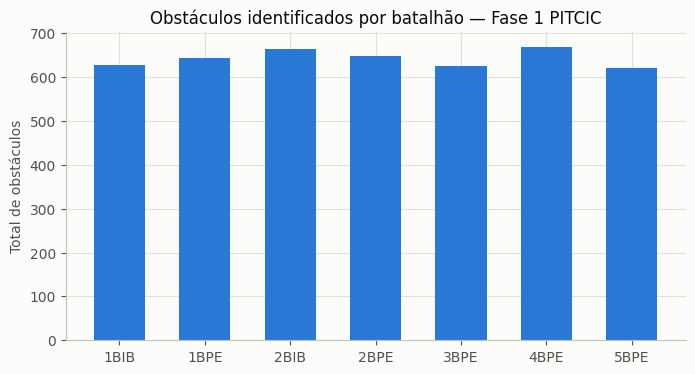

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(df_plot["batalhao_origem"], df_plot["total_obstaculos"], color=PALETTE[0], width=0.6)
ax.set_title("Obstáculos identificados por batalhão — Fase 1 PITCIC")
ax.set_ylabel("Total de obstáculos")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

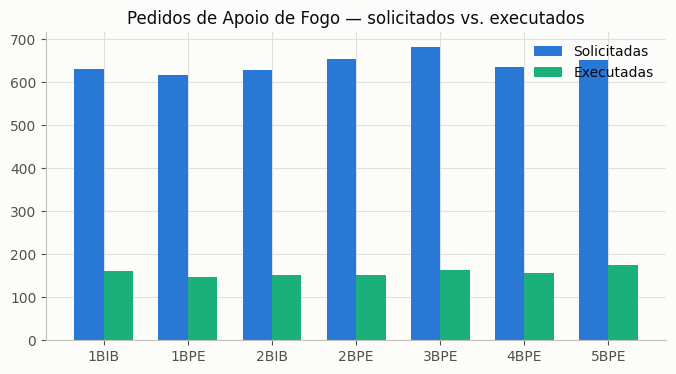

In [13]:
x = range(len(df_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar([i - width / 2 for i in x], df_plot["total_missoes_fogo"], width, label="Solicitadas", color=PALETTE[0])
ax.bar([i + width / 2 for i in x], df_plot["fogos_executados"], width, label="Executadas", color=PALETTE[4])
ax.set_xticks(list(x))
ax.set_xticklabels(df_plot["batalhao_origem"])
ax.set_title("Pedidos de Apoio de Fogo — solicitados vs. executados")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

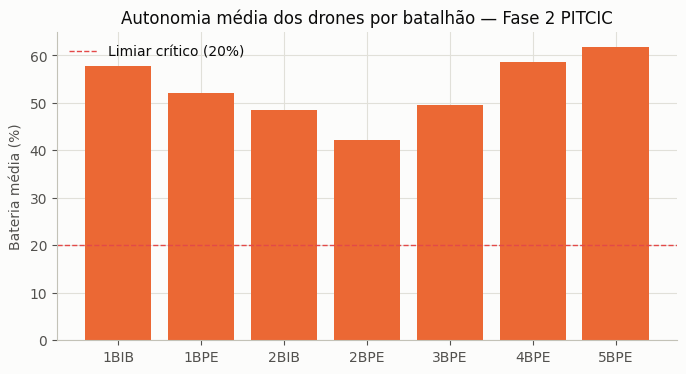

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(df_plot["batalhao_origem"], df_plot["bateria_media_pct"], color=PALETTE[5])
ax.axhline(20, color=PALETTE[7], linestyle="--", linewidth=1, label="Limiar crítico (20%)")
ax.set_title("Autonomia média dos drones por batalhão — Fase 2 PITCIC")
ax.set_ylabel("Bateria média (%)")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

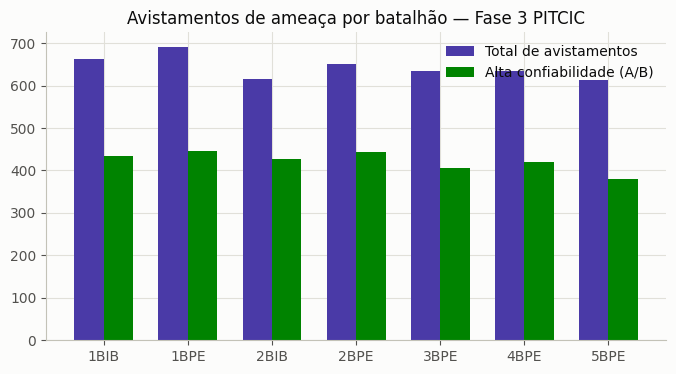

In [15]:
x = range(len(df_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar([i - width / 2 for i in x], df_plot["total_ameacas_intel"], width, label="Total de avistamentos", color=PALETTE[6])
ax.bar([i + width / 2 for i in x], df_plot["ameacas_alta_confiabilidade"], width, label="Alta confiabilidade (A/B)", color=PALETTE[1])
ax.set_xticks(list(x))
ax.set_xticklabels(df_plot["batalhao_origem"])
ax.set_title("Avistamentos de ameaça por batalhão — Fase 3 PITCIC")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

## 5. Mais recursos do Iceberg

Além do histórico de snapshots já visto na seção 2, o formato Iceberg — via Trino,
sem nenhum código extra — dá acesso a mais alguns recursos que uma tabela comum não tem.

### 5.1 Time travel de verdade

Não é só teoria: dá pra consultar a tabela exatamente como ela estava num snapshot
passado e comparar com o estado atual, sem precisar de backup nenhum. Útil pra
auditoria (ex.: "os números mudaram depois daquele deploy — o que exatamente mudou?")
ou pra investigar um bug de dado que já foi corrigido, mas cuja versão anterior
ainda importa entender.

In [16]:
if len(df_snapshots) >= 2:
    snapshot_anterior = int(df_snapshots["snapshot_id"].iloc[1])   # penúltimo
    snapshot_atual = int(df_snapshots["snapshot_id"].iloc[0])       # mais recente

    comparacao = query_df(f"""
        SELECT 'snapshot anterior' AS versao, SUM(total_obstaculos) AS soma_obstaculos, COUNT(*) AS linhas
        FROM gold.pitcic FOR VERSION AS OF {snapshot_anterior}
        UNION ALL
        SELECT 'atual' AS versao, SUM(total_obstaculos) AS soma_obstaculos, COUNT(*) AS linhas
        FROM gold.pitcic FOR VERSION AS OF {snapshot_atual}
    """)
else:
    comparacao = "Só existe 1 snapshot ainda — rode o dag_gold_refresh de novo para ter algo pra comparar."
comparacao

,versao,soma_obstaculos,linhas
0,snapshot anterior,4500,7
1,atual,4500,7


### 5.2 Metadados ricos: um arquivo Parquet por vez, sem escanear nada

Iceberg mantém estatísticas por arquivo de dado e por partição — min/max/nulos por
coluna, contagem de linhas, tamanho em bytes — tudo isso é o que permite ao Trino
"podar" partições e arquivos inteiros antes de ler um byte, só olhando metadados.
Aqui usamos `silver.relt_intel` (particionada por dia de chegada + batalhão) como
exemplo.

In [17]:
query_df("""
    SELECT partition, record_count, file_count, total_size
    FROM iceberg.silver."relt_intel$partitions"
    ORDER BY record_count DESC
""")

,partition,record_count,file_count,total_size
0,"(timestamp_chegada_day: datetime.date(2026, 7,...",691,1,52433
1,"(timestamp_chegada_day: datetime.date(2026, 7,...",663,1,50807
2,"(timestamp_chegada_day: datetime.date(2026, 7,...",651,1,50236
3,"(timestamp_chegada_day: datetime.date(2026, 7,...",634,1,48996
4,"(timestamp_chegada_day: datetime.date(2026, 7,...",634,1,49112
5,"(timestamp_chegada_day: datetime.date(2026, 7,...",615,1,47918
6,"(timestamp_chegada_day: datetime.date(2026, 7,...",612,1,47302


In [18]:
query_df("""
    SELECT file_path, record_count, file_size_in_bytes
    FROM iceberg.silver."relt_intel$files"
    ORDER BY record_count DESC
    LIMIT 5
""")

,file_path,record_count,file_size_in_bytes
0,s3a://lakehouse/warehouse/silver.db/relt_intel...,691,52433
1,s3a://lakehouse/warehouse/silver.db/relt_intel...,663,50807
2,s3a://lakehouse/warehouse/silver.db/relt_intel...,651,50236
3,s3a://lakehouse/warehouse/silver.db/relt_intel...,634,48996
4,s3a://lakehouse/warehouse/silver.db/relt_intel...,634,49112


### 5.3 Evolução de schema sem reescrever nada

Numa tabela Hive-style tradicional, adicionar uma coluna pode exigir reescrever
partições inteiras. No Iceberg é uma operação só de metadados — instantânea,
independente do tamanho da tabela — porque cada arquivo de dado sabe o próprio
schema no momento em que foi escrito; a tabela não depende de todo mundo ter o
schema mais novo.

Este bloco cria uma cópia descartável de `gold.pitcic` só pra demonstrar, evolui o
schema dela, e no final apaga a cópia — não toca na tabela real.

In [19]:
def exec_sql(sql: str):
    """Executa DDL/DML e drena o resultado (o Trino exige isso mesmo sem SELECT)."""
    cur = conn.cursor()
    cur.execute(sql)
    cur.fetchall()


exec_sql("DROP TABLE IF EXISTS gold.pitcic_demo")
exec_sql("CREATE TABLE gold.pitcic_demo AS SELECT * FROM gold.pitcic")

print("Snapshots antes do ALTER TABLE:")
print(query_df('SELECT COUNT(*) AS qtde FROM iceberg.gold."pitcic_demo$snapshots"'))

exec_sql("ALTER TABLE gold.pitcic_demo ADD COLUMN observacao VARCHAR")

print("\nSnapshots depois do ALTER TABLE (mesmo número — é só metadado, nada foi reescrito):")
print(query_df('SELECT COUNT(*) AS qtde FROM iceberg.gold."pitcic_demo$snapshots"'))

print("\nColuna nova já aparece no schema:")
print(query_df("DESCRIBE gold.pitcic_demo").tail(3))

exec_sql("DROP TABLE gold.pitcic_demo")
print("\nCópia de demonstração removida — a gold.pitcic real nunca foi tocada.")

Snapshots antes do ALTER TABLE:


   qtde
0     1



Snapshots depois do ALTER TABLE (mesmo número — é só metadado, nada foi reescrito):


   qtde
0     1

Coluna nova já aparece no schema:


              Column                         Type Extra Comment
17  fogos_executados                       bigint              
18     atualizado_em  timestamp(6) with time zone              
19        observacao                      varchar              



Cópia de demonstração removida — a gold.pitcic real nunca foi tocada.


### 5.4 E a manutenção?

Snapshots antigos acumulam arquivos de dados/metadados no MinIO indefinidamente se
ninguém expirar. Em produção isso é feito pela `dag_iceberg_maintenance.py`
(`expire_snapshots` → `remove_orphan_files` → `rewrite_manifests` →
`rewrite_data_files`/compactação), rodando via Spark contra todas as tabelas
Bronze/Silver/Gold. Não replicamos isso aqui pra não mexer nos snapshots reais
usados nas seções anteriores — mas os mesmos procedimentos existem como
[system procedures do conector Iceberg no Trino](https://trino.io/docs/current/connector/iceberg.html#alter-table-execute)
(`ALTER TABLE ... EXECUTE optimize`, `expire_snapshots`, `remove_orphan_files`),
se algum dia for útil rodar isso direto do notebook.